# redshift (z) 
$\rightarrow$ **calcul du redshift de galaxies**

## les cibles

3C 273 est un Quasar de type FSRQ (Flat Spectrum Radio Quasar)
- C'est un Noyau Galactique Actif (AGN) extrêmement lumineux.
- Le spectre de 3C 273 est dominé par des raies d'émission très larges ( $\text{H}\alpha$, $\text{H}\beta$, $\text{MgII}$, $\text{CIII}]$...).
- Cette largeur indique un gaz se déplaçant à des milliers de kilomètres par seconde dans la Région à Raies Larges (BLR).

-> Le gaz autour du trou noir tourne à plus de 3000 km/s. C'est ce qui différencie un Quasar (raies larges) d'une galaxie normale (raies fines).

-> On peut aussi estimer la masse du trou noir avec le théorème du Viriel, où la masse est liée à la vitesse du gaz ($V$) et au rayon de la BLR ($R_{BLR}$)


NGC 7215 est classée comme une Galaxie de Seyfert de Type 1.5.
- C'est aussi un type de galaxie dont le noyau est très brillant (un Noyau Galactique Actif ou AGN).
- Ce noyau est alimenté par un trou noir supermassif (SMBH) qui accrète de la matière.
- La classification **Seyfert** se base sur l'apparence des raies d'émission dans le spectre, qui proviennent de différentes régions autour du trou noir :
    - Raies Étroites (NLR - Narrow Line Region) : Gaz éloigné qui donne des raies fines (comme $[\text{OIII}]$ et $[\text{SII}]$) .
    - Raies Larges (BLR - Broad Line Region) : Gaz très proche du trou noir, se déplaçant très rapidement, ce qui élargit fortement les raies d'hydrogène


## les données

|||
|---|---|
|OBJECT|	3c273|
|EXPTIME2|	5 x 60 s|
|BSS_ITRP|	500|
|SPE_RPOW|	500|
|BSS_VHEL|	0|
|DATE-OBS|	2017-04-07|
|BSS_SITE|	CALC|
|BSS_INST|	ED80 + Dados200 + 25mic + ATIK 420m|
|||


## création du dashboard
- lancer la cellule suivante
- souris sur '**Colormap**', bouton droit, menu "**Create New View for Cell Output**"
- déplacer le nouvel onglet créé '**Output View**' pour le garder visible pendant que vous naviguez et exécutez les cellules de code

En cas de souci d'affichage $\rightarrow$  '**CTRL-R**'


In [5]:
%matplotlib widget
from spectro_dashboard import SpectroDashboard

db = SpectroDashboard()
db.show()


# chargement d'un brut et du spectre calibré

In [7]:
# imports
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from specutils import Spectrum
from astropy.modeling.models import Gaussian1D, Voigt1D, Lorentz1D, Const1D
from astropy.modeling.fitting import LevMarLSQFitter # L'outil de fit correct

from specutils.fitting import fit_generic_continuum
from astropy.modeling.models import Polynomial1D # Exemple de modèle de fit
from specutils import SpectralRegion
from astropy.stats import mad_std
from specutils.analysis import snr, snr_derived
from specutils.spectra import SpectralRegion

from astropy.constants import c
from astropy.cosmology import Planck18

from astropy.nddata import CCDData
import ccdproc as ccdproc

# on affiche un brut 

img = CCDData.read('data/plouis/3c273-001.fit', unit=u.Unit('adu'))
db.show_image(img, img.meta['OBJECT'])


# on affiche le spectre de la galaxie
db.clear_spectra()

# lecture de fichiers DAT (csv)
#spec_name = 'data/plouis/_ngc7215-_20161228_896_P.Louis.dat'
#spec_name = 'data/plouis/_ngc4151_20170121_974_P.Louis.dat'
spec_name = 'data/plouis/_3c273_20170407_870_PLouis.dat'

_spc_array = np.loadtxt(spec_name)
_spec1d = Spectrum(spectral_axis=_spc_array[:,0] * u.Unit('Angstrom'), 
                 flux=_spc_array[:,1] * u.Unit('mJy')
                         )

db.show_spectrum(_spec1d.wavelength, _spec1d.flux, label=spec_name)


--> Affichage de l'image 3c273 : bin=1, shape=(609, 809), min=1112, avg=1375.9, max=65535, std=436.9
--> Affichage du spectre data/plouis/_3c273_20170407_870_PLouis.dat : dispersion=0.8421 Å/px


# retrait du continuum

In [8]:
#db.clear_spectra()

# on reprend le spectre créé ci-dessus
spectrum = _spec1d #Spectrum1D(flux=flux, spectral_axis=wavelength)

continuum_model_fit = Polynomial1D(degree=3) 

# on défini les zones à exclure
windows_tuples = [
    (4850 * u.Angstrom, 4900 * u.Angstrom), # Exclusion de Hβ
    (4950 * u.Angstrom, 5040 * u.Angstrom)  # Exclusion des [OIII]
]

# on créé les deux regions
exclusion_regions = [SpectralRegion(start, end) for start, end in windows_tuples]

# on ajuste le modèle uniquement aux régions qui NE SONT PAS dans exclusion_windows.
fitted_continuum = fit_generic_continuum(
    spectrum,
    model=continuum_model_fit,
    exclude_regions=exclusion_regions
)

# Évaluation du modèle ajusté sur l'intégralité du spectre
continuum_flux_to_subtract = fitted_continuum(spectrum.spectral_axis)

# Obtention du spectre net
spectrum_sans_cont = Spectrum(
    flux=spectrum.flux / continuum_flux_to_subtract,
    spectral_axis=spectrum.spectral_axis
)

region_continuum = SpectralRegion(4500*u.Angstrom, 4700*u.Angstrom)

db.show_spectrum(spectrum.spectral_axis.to(u.Angstrom).value, continuum_flux_to_subtract.value, label='continuum')
db.show_spectrum(spectrum_sans_cont.spectral_axis, spectrum_sans_cont.flux, label='continuum retiré')


--> Affichage du spectre continuum : dispersion=0.8421 Å/px
--> Affichage du spectre continuum retiré : dispersion=0.8421 Å/px


# ajustement 

In [9]:
# 
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.modeling import models
from specutils import Spectrum, SpectralRegion
from specutils.manipulation import extract_region
from specutils.fitting import fit_lines
from specutils.analysis import centroid, fwhm, equivalent_width, snr, snr_derived

c_kms = 299792.458
#lambda_rest = 5006.84 # OIII
lambda_rest = 4861.35 # Hbeta
region_cont = SpectralRegion(4250.0 * u.AA, 4950.0 * u.AA)
fwhm_neon_pix = 4  # largeur raie néon en px, retourné par ISIS
#disp_physique = 0.8421 # dispersion du DADOS200, retourné par ISIS
delta_lambda = np.mean(np.diff(spectrum_sans_cont.spectral_axis)) # Dispersion (A/pix)
print(f"Dispersion : {delta_lambda:.2f} Å/px")

# Calcul des erreurs systématiques (DADOS 200)
fwhm_inst_angstrom = fwhm_neon_pix * delta_lambda
sigma_syst_rv = (fwhm_inst_angstrom / 10.0 / lambda_rest) * c_kms # Règle du 1/10eme
fwhm_inst_a = fwhm_neon_pix * delta_lambda  # Résolution en Angströms
err_v = c * (sigma_syst_rv / (2 * lambda_rest))        

sub_spectrum = extract_region(spectrum_sans_cont, region_cont)
flux_zone = sub_spectrum.flux.value
snr_reel = np.mean(flux_zone) / np.std(flux_zone)

print(f"SNR : {snr_reel:.0f}")

# Modèle : Gaussienne en emission + Constante à 1
g_init = models.Gaussian1D(amplitude=0.8, mean=5630, stddev=1.0) + models.Const1D(1.0)
g_fit = fit_lines(spectrum_sans_cont, g_init) # On fit sur le spectre normalisé

# on récupère les résultats de l'ajustement
center_fit = g_fit[0].mean.value
fwhm_fit = g_fit[0].fwhm.value
vr_fit = c_kms * (center_fit - lambda_rest) / lambda_rest
v_exp_fit = (c_kms * (fwhm_fit / lambda_rest))

# incertitudes statistiques
err_fwhm_fit = fwhm_fit / snr_reel
err_cent_fit_stat = fwhm_fit / (2.35 * snr_reel)
err_vr_fit_stat = (c_kms * (err_cent_fit_stat / lambda_rest))
err_v_exp_final = (c_kms * (err_fwhm_fit / lambda_rest))

# incertitudes RMS (statistiques + systématiques)
err_vr_fit_total = np.sqrt(err_vr_fit_stat**2 + sigma_syst_rv.value**2)
err_v_exp_fit_total = np.sqrt(err_v_exp_final**2 + sigma_syst_rv.value**2)

print("-" * 30 + "AJUSTEMENT " + "-" * 30)
print(f"FWHM              : {fwhm_fit:.2f} +/- {err_fwhm_fit:.2f} Å")
print(f"Vitesse Expansion : {v_exp_fit:.2f} +/- {err_v_exp_final:.2f} km/s")


v_z = (center_fit - lambda_rest) / lambda_rest
v_err_z = err_vr_fit_total / lambda_rest

v_dist = Planck18.luminosity_distance(v_z).value
v_err_dist = (Planck18.luminosity_distance(v_z + v_err_z).value - 
              Planck18.luminosity_distance(v_z - v_err_z).value) / 2

print(f"Redshift (z)      : {v_z:.6f} +/- {v_err_z:.6f}")
print(f"Vitesse Radiale   : {vr_fit:.2f} +/- {err_vr_fit_total:.2f} km/s")
print(f"Distance (D_L)    : {v_dist:.2f} +/- {v_err_dist:.2f} Mpc")

db.clear_spectra()

# on recharge le spectre sans le continnum
db.show_spectrum(spectrum_sans_cont.spectral_axis, spectrum_sans_cont.flux, label='continuum retiré')
# on affiche le fit
l_rest = db.ax_spec.axvline(lambda_rest, color='red', ls='--', alpha=1, lw=1)
y_fit = g_fit(spectrum_sans_cont.spectral_axis)
db.show_spectrum(
    spectrum_sans_cont.spectral_axis,
    y_fit,
    label='fit'
)


Dispersion : 0.84 Angstrom Å/px
SNR : 16
------------------------------AJUSTEMENT ------------------------------
FWHM              : 57.43 +/- 3.52 Å
Vitesse Expansion : 3541.82 +/- 216.83 km/s
Redshift (z)      : 0.158888 +/- 0.019455
Vitesse Radiale   : 47633.50 +/- 94.58 km/s
Distance (D_L)    : 784.85 +/- 105.40 Mpc
--> Affichage du spectre continuum retiré : dispersion=0.8421 Å/px
--> Affichage du spectre fit : dispersion=0.8421 Å/px


# résidus

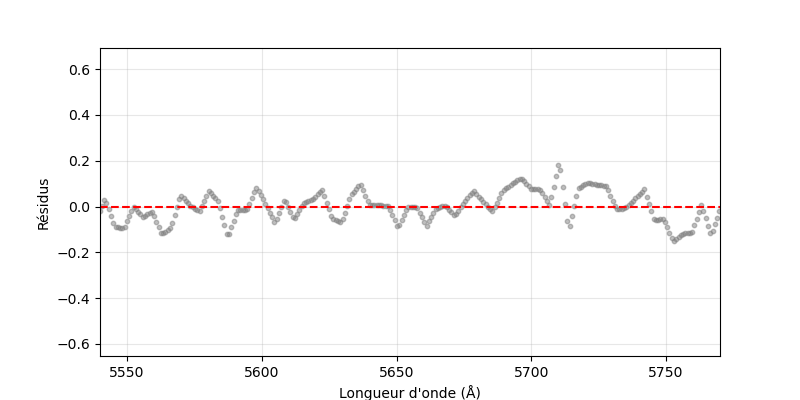

In [10]:
# on récupère les résidus en divisant le brut par le fit
residus = spectrum_sans_cont.flux - y_fit

# on affiche
fig, ax = plt.subplots(1, 1, figsize=(8, 4))#, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax.scatter(spectrum_sans_cont.spectral_axis, residus, s=10, color='gray', alpha=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_ylabel('Résidus')
ax.set_xlabel('Longueur d\'onde (Å)')
ax.set_xlim(5540, 5770)
ax.grid(alpha=0.3)
plt.show()

# on vérifie que la zone de la raie est 'plate' dans la région de la raie -> le fit encadre bien la raie


## masse du trou noir
Pour calcul de la masse du trou noir, on utilise la méthode de la masse virielle :

- le gaz tourne si vite (FWHM) parce qu'il est retenu par une masse énorme.
- plus le trou noir est massif, plus le gaz doit tourner vite pour ne pas tomber dedans.
- la formule simplifiée :
    - Pour les quasars, une relation standard (basée sur les travaux de Vestergaard & Peterson) utilise la raie $H\beta$ et la distance de l'objet.
    - Voici une version adaptée  :$$M_{BH} \approx 10^{6.91} \times \left( \frac{\text{FWHM}}{1000 \text{ km/s}} \right)^2 \times \sqrt{\frac{L_{5100}}{10^{44} \text{ erg/s}}}$$
    - Comme nous n'avons pas la mesure exacte de la luminosité intrinsèque ($L_{5100}$), on peut utiliser une valeur de référence pour 3C 273 qui est très stable, ou simplifier en utilisant la largeur de raie seule si on accepte une marge d'erreur.



In [11]:
# --- ESTIMATION DE LA MASSE DU TROU NOIR ---

# Constante de calibration pour H-beta (Vestergaard 2006)
log_a = 6.91 
# On utilise la FWHM en km/s 
v_fwhm_kms = v_exp_fit #3056.27 

# Pour 3C 273, la luminosité intrinsèque au continuum est d'environ 10^46 erg/s
# On peut l'estimer ou utiliser cette valeur de référence en log
log_L5100 = 45.9  

# Calcul de la masse en Log10(Molaire)
log_M_BH = log_a + 2 * np.log10(v_fwhm_kms / 1000) + 0.5 * (log_L5100 - 44)

m_bh_solaires = 10**log_M_BH

# Erreur estimée (environ 0.3 dex pour cette méthode)
m_bh_min = 10**(log_M_BH - 0.3)
m_bh_max = 10**(log_M_BH + 0.3)

print(f"Masse estimée : {m_bh_solaires/1e6:.1f} Millions de masses solaires")


Masse estimée : 908.8 Millions de masses solaires


pour conclure :
- L'échelle du monstre : Le trou noir de notre Galaxie, Sgr A*, fait "seulement" 4,1 millions de masses solaires.
- Si on le plaçait au centre du système solaire, son horizon des événements s'étendrait au-delà de l'orbite de Neptune...
